Time series loaded. Date range: 1985-01-01 00:00:00 to 2018-01-01 00:00:00


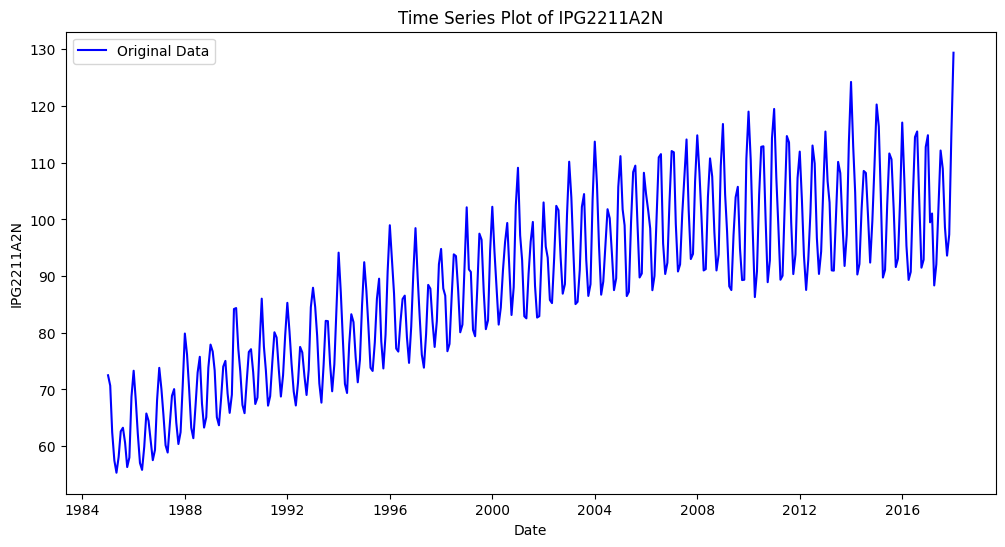

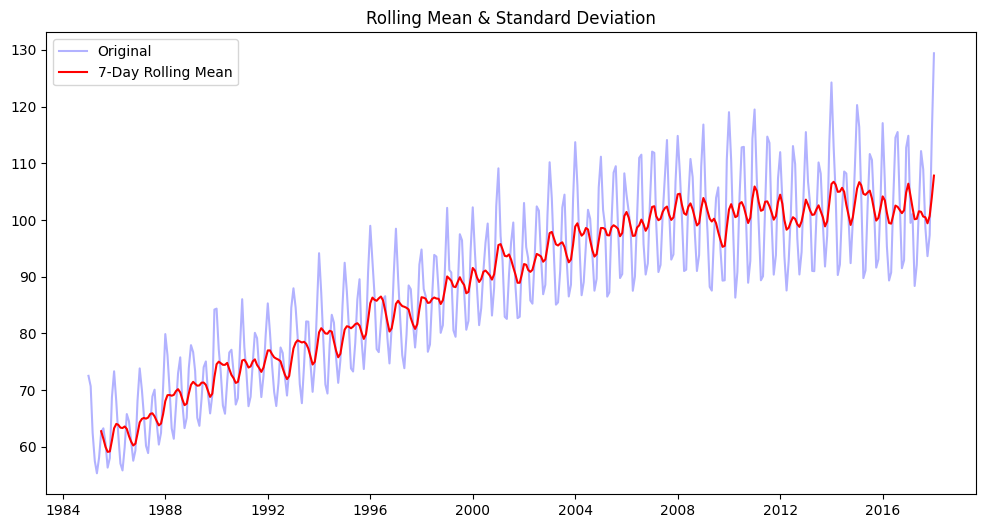

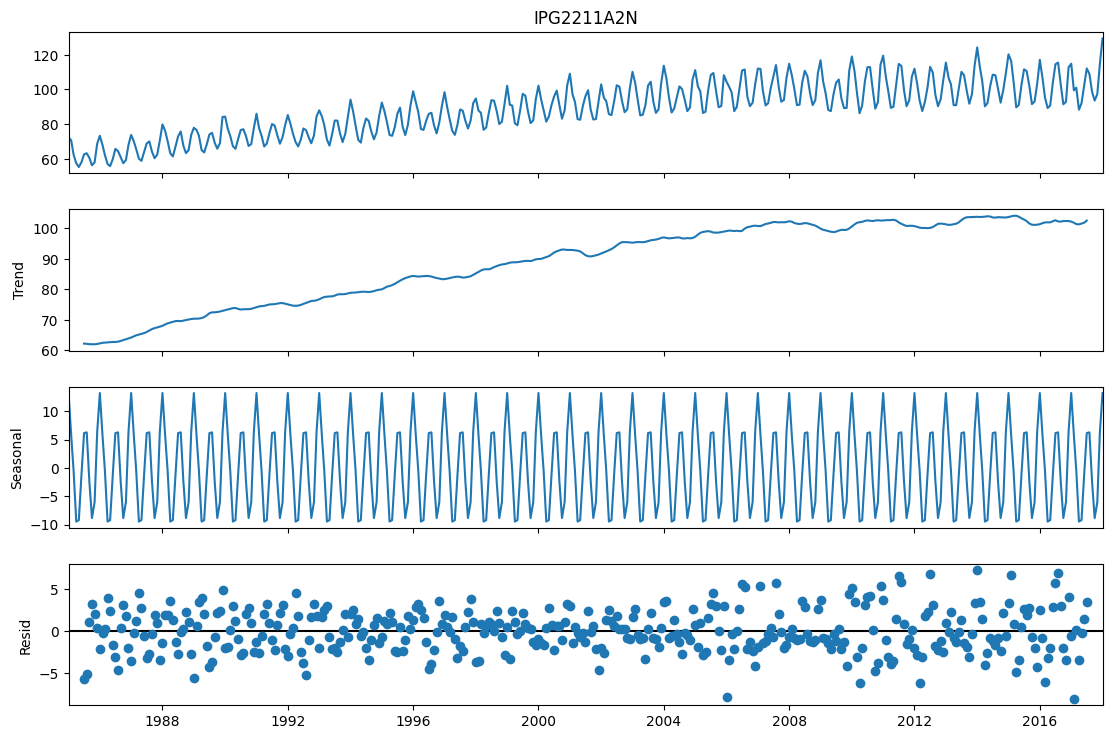


--- Dickey-Fuller Test for Stationarity ---
ADF Statistic: -2.2570
p-value: 0.1862
Result: Data is non-stationary (Needs differencing before ARIMA)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 1. SETUP DATA
# Load your dataset
# Note: For Time Series, one column MUST be a Date/Time
df = pd.read_csv('Electric_Production.csv')

# UPDATE THESE:
DATE_COL = 'DATE'     # The name of your date column
VALUE_COL = 'IPG2211A2N'   # The numerical value you want to analyze

# 2. PRE-PROCESSING FOR TIME SERIES
# Convert the date column to actual datetime objects
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# Set the date as the index (Required for most time series libraries)
df.set_index(DATE_COL, inplace=True)

# Sort by date to ensure the sequence is correct
df.sort_index(inplace=True)

print(f"Time series loaded. Date range: {df.index.min()} to {df.index.max()}")

# 3. VISUALIZATION (Experiment 8/9/10 context)
plt.figure(figsize=(12, 6))
plt.plot(df[VALUE_COL], color='blue', label='Original Data')
plt.title(f'Time Series Plot of {VALUE_COL}')
plt.xlabel('Date')
plt.ylabel(VALUE_COL)
plt.legend()
plt.show()

# 4. ROLLING STATISTICS (Smooth out the noise)
# Window=7 might represent a weekly moving average
rolling_mean = df[VALUE_COL].rolling(window=7).mean()
rolling_std = df[VALUE_COL].rolling(window=7).std()

plt.figure(figsize=(12, 6))
plt.plot(df[VALUE_COL], color='blue', alpha=0.3, label='Original')
plt.plot(rolling_mean, color='red', label='7-Day Rolling Mean')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.show()

# 5. SEASONAL DECOMPOSITION
# This breaks the data into: Trend, Seasonality, and Residuals (Noise)
# Period depends on your data (e.g., 12 for monthly data with yearly patterns)
decomposition = seasonal_decompose(df[VALUE_COL], model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# 6. STATIONARITY CHECK (Required for ARIMA - Experiment 6)
# Augmented Dickey-Fuller test
print("\n--- Dickey-Fuller Test for Stationarity ---")
result = adfuller(df[VALUE_COL])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

if result[1] <= 0.05:
    print("Result: Data is stationary (Ready for ARIMA)")
else:
    print("Result: Data is non-stationary (Needs differencing before ARIMA)")